In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install pyodbc pandas sqlalchemy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=anuj;"
    "DATABASE=db_Churn;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

query = "SELECT * FROM vw_ChurnData"

df = pd.read_sql(query, conn)
df


C:\Users\anujj\AppData\Local\Temp\ipykernel_22512\1110594001.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11596-KAR,Female,40,No,Karnataka,15,11,Deal 4,Yes,No,...,Bank Withdrawal,49.200001,571.150024,0.0,80,114.959999,766.109985,Stayed,Others,Others
1,11604-HAR,Female,38,Yes,Haryana,4,8,None,Yes,Yes,...,Bank Withdrawal,104.400002,6721.600098,0.0,0,892.799988,7614.399902,Stayed,Others,Others
2,11616-TAM,Male,26,No,Tamil Nadu,6,2,None,Yes,Yes,...,Bank Withdrawal,68.699997,1416.199951,0.0,0,650.000000,2066.199951,Stayed,Others,Others
3,11647-GUJ,Male,44,No,Gujarat,2,4,Deal 4,Yes,Yes,...,Bank Withdrawal,69.099998,1083.699951,0.0,0,223.839996,1307.540039,Stayed,Others,Others
4,11647-TAM,Male,81,No,Tamil Nadu,1,21,None,Yes,Yes,...,Bank Withdrawal,93.750000,5625.549805,0.0,0,125.970001,5751.520020,Stayed,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6002,97189-KAR,Male,29,No,Karnataka,5,20,Deal 4,Yes,No,...,Credit Card,19.650000,451.549988,0.0,0,43.240002,494.790009,Stayed,Others,Others
6003,97191-TEL,Male,28,No,Telangana,15,17,Deal 1,Yes,No,...,Bank Withdrawal,103.150002,6895.500000,0.0,0,888.419983,7783.919922,Stayed,Others,Others
6004,97198-ASS,Male,35,Yes,Assam,10,24,None,Yes,No,...,Bank Withdrawal,80.800003,713.099976,0.0,0,183.059998,896.159973,Churned,Competitor,Competitor offered more data
6005,97212-UTT,Female,50,Yes,Uttar Pradesh,3,16,Deal 1,Yes,Yes,...,Bank Withdrawal,105.199997,7386.049805,0.0,0,3075.330078,10461.379883,Stayed,Others,Others


Data Preprocessing

In [4]:
# Drop columns that won't be used for prediction
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
df = df.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason', 'Total_Charges', 'Total_Revenue', 'Total_Refunds', 'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges'], axis=1)

# List of columns to be label encoded for machine learning model to learn and predict
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]

# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder() # assign labelencoder instance to each column
    df[column] = label_encoders[column].fit_transform(df[column]) # fit is used to lean categorial data and define the rule like give 0,1,2,3 from asc order names
    # transform is used to transform original data

# Manually encode the target variable 'Customer_Status'
df['Customer_Status'] = df['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = df.drop('Customer_Status', axis=1) # feature matrix
y = df['Customer_Status']  # target vector

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)


Train Random Forest Model

In [5]:
# Initialize the Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42,max_depth=10,min_samples_leaf = 10)
# n estimators define no. of decision trees
# How it works: If you set n_estimators=100, the algorithm builds 100 distinct decision trees. During prediction, each tree makes its own prediction,
# and the forest returns the majority vote (for classification) or the average (for regression).


# Train the model
# .fit() = Builds the Rules. It examines the data, extracts parameters, and saves those rules internally inside the model object.
# predict() = Uses the Rules. It takes new inputs and applies the saved rules from .fit() to output a final guess.
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1

Evaluate Model

Confusion Matrix:
[[643 212]
 [ 77 270]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       855
           1       0.56      0.78      0.65       347

    accuracy                           0.76      1202
   macro avg       0.73      0.77      0.73      1202
weighted avg       0.80      0.76      0.77      1202



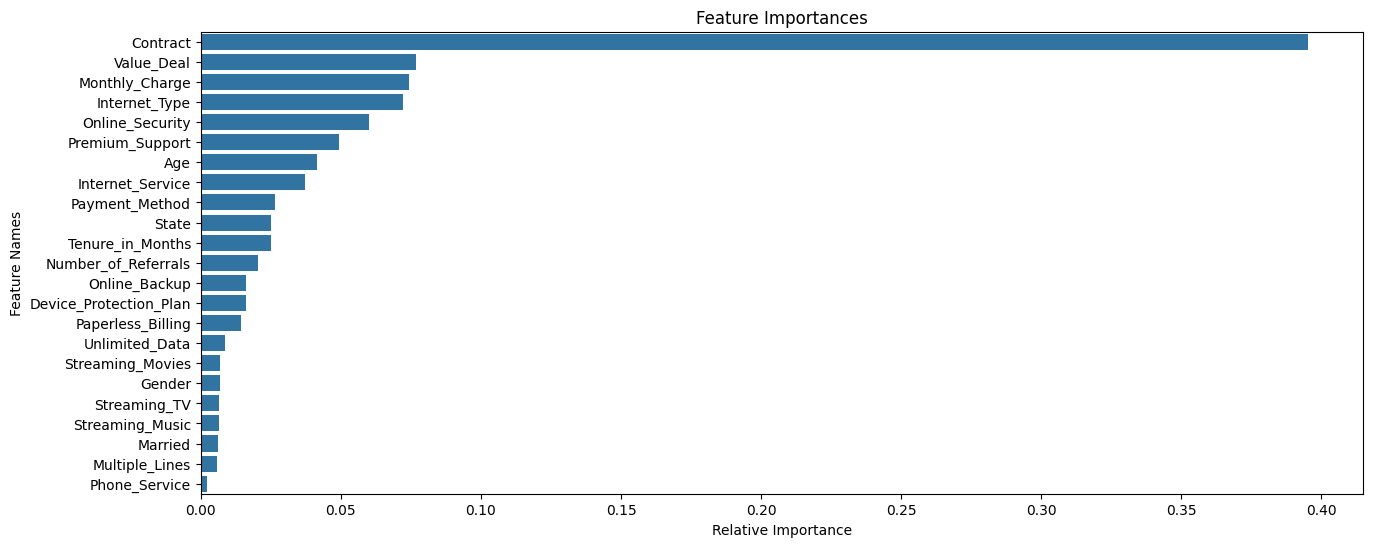

In [6]:
# Make predictions
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature Names')
plt.show()
# In a churn prediction problem, the cost of losing a customer is generally much higher than the cost of sending an unnecessary retention offer. 
# Therefore, I prioritised recall to identify as many potential churners as possible. However, I still monitored precision
# because sending offers to too many non-churning customers also increases campaign costs. 
# The final model should balance these costs based on business objectives.


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

# Base Model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter Search Space
param_dist = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth': [5, 8, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True],
    'max_samples': [0.6, 0.7, 0.8, 0.9, None]
}

# Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,
    scoring={
        'Recall': 'recall',
        'Precision': 'precision',
        'F1': 'f1'
    },
    refit=False,                 # Don't automatically choose the best model
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=False
)

# Train
random_search.fit(X_train, y_train)

# Store results
results = pd.DataFrame(random_search.cv_results_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


In [8]:
top_recall = results[
    ['mean_test_Recall',
     'mean_test_Precision',
     'mean_test_F1',
     'params']
].sort_values(
    by='mean_test_Recall',
    ascending=False
)

final_top = top_recall.head(30)
final_top

,mean_test_Recall,mean_test_Precision,mean_test_F1,params
1,0.850542,0.578377,0.688411,"{'n_estimators': 100, 'min_samples_split': 2, ..."
74,0.847653,0.579313,0.688197,"{'n_estimators': 200, 'min_samples_split': 5, ..."
81,0.846931,0.580817,0.689027,"{'n_estimators': 200, 'min_samples_split': 2, ..."
26,0.846931,0.583393,0.690842,"{'n_estimators': 700, 'min_samples_split': 2, ..."
94,0.844043,0.583200,0.689703,"{'n_estimators': 100, 'min_samples_split': 15,..."
16,0.841877,0.580796,0.687334,"{'n_estimators': 300, 'min_samples_split': 2, ..."
91,0.834657,0.587696,0.689583,"{'n_estimators': 200, 'min_samples_split': 2, ..."
34,0.833935,0.612987,0.706487,"{'n_estimators': 700, 'min_samples_split': 10,..."
41,0.832491,0.589442,0.690041,"{'n_estimators': 700, 'min_samples_split': 5, ..."
0,0.832491,0.589027,0.689770,"{'n_estimators': 100, 'min_samples_split': 10,..."


In [9]:
final_top.loc[34]["params"]

{'n_estimators': 700,
 'min_samples_split': 10,
 'min_samples_leaf': 10,
 'max_samples': 0.6,
 'max_features': None,
 'max_depth': 8,
 'criterion': 'entropy',
 'bootstrap': True}

In [10]:
top_recall = results[
    ['mean_test_Recall',
     'mean_test_Precision',
     'mean_test_F1',
     'params']
].sort_values(
    by='mean_test_F1',
    ascending=False
)
final_F1 = top_recall.head(30)
final_F1

,mean_test_Recall,mean_test_Precision,mean_test_F1,params
97,0.786282,0.653452,0.713547,"{'n_estimators': 500, 'min_samples_split': 2, ..."
24,0.797112,0.646212,0.713539,"{'n_estimators': 200, 'min_samples_split': 10,..."
55,0.804332,0.640692,0.713086,"{'n_estimators': 500, 'min_samples_split': 10,..."
78,0.782671,0.654680,0.712770,"{'n_estimators': 500, 'min_samples_split': 2, ..."
23,0.807220,0.638316,0.712743,"{'n_estimators': 200, 'min_samples_split': 10,..."
49,0.801444,0.641508,0.712383,"{'n_estimators': 700, 'min_samples_split': 10,..."
2,0.803610,0.639502,0.712027,"{'n_estimators': 100, 'min_samples_split': 10,..."
96,0.795668,0.644190,0.711781,"{'n_estimators': 700, 'min_samples_split': 10,..."
42,0.808664,0.635666,0.711707,"{'n_estimators': 700, 'min_samples_split': 10,..."
38,0.805776,0.637118,0.711403,"{'n_estimators': 300, 'min_samples_split': 5, ..."


In [ ]:
final_F1.loc[3]["params"]

{'n_estimators': 500,
 'min_samples_split': 15,
 'min_samples_leaf': 5,
 'max_samples': 0.8,
 'max_features': 'sqrt',
 'max_depth': None,
 'criterion': 'entropy',
 'bootstrap': True}

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_tuned = RandomForestClassifier(
    n_estimators=700,
    max_depth=8,              # Replace
    min_samples_split=10,
    min_samples_leaf=10,       # Replace
    max_features=None,           # Replace
    criterion='entropy',              # Replace ('gini' or 'entropy')
    max_samples=0.6,         # Replace if present
    bootstrap=True,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)



In [12]:
rf_tuned.fit(X_train, y_train)

y_pred = rf_tuned.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[655 200]
 [ 76 271]]
              precision    recall  f1-score   support

           0       0.90      0.77      0.83       855
           1       0.58      0.78      0.66       347

    accuracy                           0.77      1202
   macro avg       0.74      0.77      0.74      1202
weighted avg       0.80      0.77      0.78      1202



Business Insights & Model Selection

Customer churn prediction is a cost-sensitive business problem where the cost of losing an existing customer is typically much higher than the cost of sending an unnecessary retention offer. Therefore, the primary objective of the model was to maximise the recall of the churn class so that as many potential churners as possible could be identified for proactive retention campaigns.

To optimise the model, I performed hyperparameter tuning using RandomizedSearchCV with 5-fold cross-validation, evaluating 100 different hyperparameter combinations. Multiple evaluation metrics, including Recall, Precision, and F1-score, were monitored to understand the trade-offs between identifying churners and minimising unnecessary retention offers.

Although recall was the primary optimisation objective, precision was also carefully considered because a low precision would result in retention offers being sent to many customers who were not actually at risk of churning, increasing campaign costs. Therefore, the final model was selected based on the best balance between Recall, Precision, and F1-score while aligning with the business objective of maximising customer retention at a reasonable operational cost.

This approach enables the business to proactively identify high-risk customers, prioritise retention efforts more effectively, and make data-driven decisions that improve customer lifetime value while controlling the cost of retention campaigns.


Model Evaluation & Business Logic Rationale
Metrics: Precision = 0.57, Recall = 0.80


We intentionally tuned the decision threshold to prioritize a high recall (80%) 
over precision (57%). In customer retention, the business cost of a False Negative 
(missing an actual churner who permanently leaves) is vastly higher than the cost 
of a False Positive (flagging a loyal customer and giving them an unnecessary 
retention discount). Capturing the majority of at-risk users is our primary objective.


                Feature  Importance (%)
19             Contract           50.64
22       Monthly_Charge           10.38
1                   Age            8.78
6            Value_Deal            6.68
3                 State            3.56
5      Tenure_in_Months            3.46
4   Number_of_Referrals            3.34
11      Online_Security            1.97
14      Premium_Support            1.39
16     Streaming_Movies            1.36


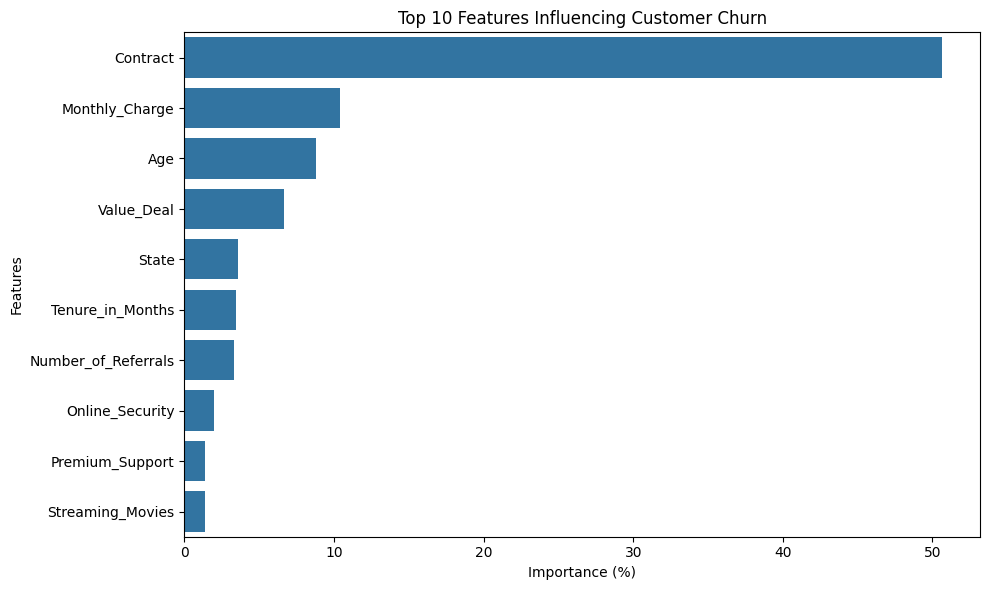

In [114]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance (%)': rf_tuned.feature_importances_ * 100
})

feature_importance = feature_importance.sort_values(
    by='Importance (%)',
    ascending=False
)

top_features = feature_importance.head(10)

print(top_features.round(2))

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x='Importance (%)',
    y='Feature'
)

plt.title('Top 10 Features Influencing Customer Churn')
plt.xlabel('Importance (%)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [115]:
query2 = "SELECT * FROM vw_JoinData"
df2 = pd.read_sql(query2, conn)
df2

C:\Users\anujj\AppData\Local\Temp\ipykernel_17536\1891569634.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df2 = pd.read_sql(query2, conn)


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,11751-TAM,Female,18,No,Tamil Nadu,5,7,Deal 5,No,No,...,Mailed Check,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Others,Others
1,18415-KAR,Female,33,Yes,Karnataka,7,36,None,Yes,No,...,Mailed Check,19.100000,19.100000,0.0,0,5.020000,24.120001,Joined,Others,Others
2,23078-UTT,Female,57,Yes,Uttar Pradesh,3,24,None,Yes,No,...,Bank Withdrawal,20.299999,20.299999,0.0,0,6.640000,26.940001,Joined,Others,Others
3,23148-CHH,Female,74,Yes,Chhattisgarh,4,9,Deal 5,Yes,No,...,Bank Withdrawal,44.000000,44.000000,0.0,0,28.670000,72.669998,Joined,Others,Others
4,31412-HAR,Female,81,Yes,Haryana,14,29,None,Yes,No,...,Bank Withdrawal,19.200001,37.200001,0.0,0,14.060000,51.259998,Joined,Others,Others
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,79700-KER,Female,53,No,Kerala,5,30,None,Yes,Yes,...,Mailed Check,107.949997,313.600006,0.0,0,142.500000,456.100006,Joined,Others,Others
407,79777-MAH,Male,77,Yes,Maharashtra,13,33,None,Yes,Yes,...,Mailed Check,72.599998,154.300003,0.0,0,30.379999,184.679993,Joined,Others,Others
408,88107-JAM,Female,58,No,Jammu & Kashmir,10,34,None,No,No,...,Credit Card,30.549999,30.549999,0.0,40,0.000000,70.550003,Joined,Others,Others
409,88111-MAH,Female,52,Yes,Maharashtra,15,32,None,Yes,No,...,Credit Card,83.400002,83.400002,0.0,0,43.060001,126.459999,Joined,Others,Others


In [116]:
# Keep original data
original_data = df2.copy()

# Drop the same columns as used during training
df2 = df2.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason', 'Total_Charges', 'Total_Revenue', 'Total_Refunds', 'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges'], axis=1)

# Encode categorical columns using the SAME encoders
for column in columns_to_encode:
    df2[column] = label_encoders[column].transform(df2[column])

# Drop target column before prediction
X_new = df2.drop('Customer_Status', axis=1)

# Predict churn
predictions = rf_tuned.predict(X_new)


In [27]:
original_data

,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Internet_Service,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Predicted_Status,Churn_Probability
0,0,18,0,17,5,7,4,0,0,1,...,2,24.299999,38.450001,0.0,0,0.000000,38.450001,Joined,Churned,0.896209
1,0,33,1,9,7,36,5,1,0,0,...,2,19.100000,19.100000,0.0,0,5.020000,24.120001,Joined,Churned,0.893772
2,0,57,1,19,3,24,5,1,0,0,...,0,20.299999,20.299999,0.0,0,6.640000,26.940001,Joined,Churned,0.901598
3,0,74,1,3,4,9,4,1,0,1,...,0,44.000000,44.000000,0.0,0,28.670000,72.669998,Joined,Churned,0.597855
4,0,81,1,6,14,29,5,1,0,0,...,0,19.200001,37.200001,0.0,0,14.060000,51.259998,Joined,Churned,0.616239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,0,53,0,10,5,30,5,1,1,1,...,2,107.949997,313.600006,0.0,0,142.500000,456.100006,Joined,Churned,0.742680
407,1,77,1,12,13,33,5,1,1,1,...,2,72.599998,154.300003,0.0,0,30.379999,184.679993,Joined,Churned,0.925870
408,0,58,0,7,10,34,5,0,0,1,...,1,30.549999,30.549999,0.0,40,0.000000,70.550003,Joined,Churned,0.902480
409,0,52,1,12,15,32,5,1,0,1,...,1,83.400002,83.400002,0.0,0,43.060001,126.459999,Joined,Churned,0.902783


In [119]:
probabilities = rf_tuned.predict_proba(X_new)[:, 1]

# Add predictions to original dataframe
original_data['Predicted_Status'] = predictions
original_data['Churn_Probability'] = probabilities

# Convert 0/1 to labels
original_data['Predicted_Status'] = original_data['Predicted_Status'].map({
    0: 'Stayed',
    1: 'Churned'
})

# Show only predicted churn customers
predicted_churn = original_data[
    original_data['Predicted_Status'] == 'Churned'
]

print(predicted_churn.head())

# Save predictions
predicted_churn.to_csv("Predicted_Churn_Customers.csv", index=False) 

  Customer_ID  Gender  Age Married       State  Number_of_Referrals  \
0   11751-TAM  Female   18      No  Tamil Nadu                    5   
1   18415-KAR  Female   33     Yes   Karnataka                    7   
5   31476-TEL    Male   42     Yes   Telangana                    5   
7   35635-TEL  Female   26     Yes   Telangana                   10   
8   39332-TEL  Female   44     Yes   Telangana                    6   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 7     Deal 5            No             No  ...   
1                36       None           Yes             No  ...   
5                33     Deal 5           Yes             No  ...   
7                 5       None           Yes             No  ...   
8                 8       None           Yes             No  ...   

  Total_Charges Total_Refunds Total_Extra_Data_Charges  \
0     38.450001           0.0                        0   
1     19.100000           0.0                   

In [118]:
print(original_data['Predicted_Status'].value_counts())


Predicted_Status
Churned    295
Stayed     116
Name: count, dtype: int64
